# Unidad 2: Aprendizaje Automático
## 📉 Curva ROC y AUC
### Inteligencia Artificial — Lic. en Sistemas — FCAD/UNER

---

## 🎯 ¿Qué vamos a aprender?

La **Curva ROC** (Receiver Operating Characteristic) es la herramienta visual más poderosa para evaluar clasificadores binarios **independientemente del umbral de decisión**.

Al finalizar, vas a poder:
- ✅ Entender qué representa cada punto de una curva ROC
- ✅ Calcular la curva ROC a partir de `predict_proba()`
- ✅ Interpretar el **AUC** (Area Under the Curve) como métrica global
- ✅ Comparar clasificadores distintos sobre el mismo espacio ROC
- ✅ Distinguir cuándo un modelo supera al azar

---

## 🧠 Marco Teórico

### 📉 ¿Qué es la Curva ROC?

La curva **ROC** grafica el **True Positive Rate** (Sensibilidad) en el eje Y vs el **False Positive Rate** (1 − Especificidad) en el eje X, al variar el umbral de decisión de 0 a 1.

$$TPR = \frac{TP}{TP + FN} \quad (\text{Sensibilidad / Recall})$$

$$FPR = \frac{FP}{FP + TN} = 1 - \text{Especificidad}$$

```
TPR
 1.0 ┤        ●●●●●●●     ← umbral → 0 (sensible, muchos FP)
 0.8 ┤     ●●●
 0.6 ┤   ●●            ·
 0.4 ┤  ●       ·
 0.2 ┤ ●   ·
 0.0 ┤●·                  ← umbral → 1 (específico, pocos FP)
      └──────────────────── FPR
      0.0  0.2  0.4  0.6  1.0
       ···· = clasificador aleatorio (diagonal)
       ●●●● = buen clasificador (arquea hacia (0,1))
```

### 📐 El AUC — Area Under the Curve

El **AUC** (Area Under the ROC Curve) resume la curva completa en un único número:

| AUC | Interpretación |
|-----|----------------|
| 1.0 | Clasificador perfecto ✅ |
| 0.9 – 1.0 | Excelente |
| 0.8 – 0.9 | Bueno |
| 0.7 – 0.8 | Aceptable |
| 0.6 – 0.7 | Pobre |
| 0.5 | Igual que el azar ❌ |
| < 0.5 | Peor que el azar ⚠️ |

El AUC tiene una interpretación probabilística elegante: es la **probabilidad de que el modelo asigne un score más alto a un positivo aleatorio que a un negativo aleatorio**.

### 🆚 ROC vs Precision-Recall

| Curva | Mejor cuando... |
|-------|-----------------|
| **ROC / AUC** | Clases balanceadas o cuando TN importa |
| **Precision-Recall** | Clases muy desbalanceadas (positivos raros) |

> 📌 **Referencias:**
> - Fawcett, T. (2006). [An introduction to ROC analysis](https://doi.org/10.1016/j.patrec.2005.10.010). *Pattern Recognition Letters*, 27(8), 861–874.
> - Scikit-learn: [roc_curve](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html)
> - Scikit-learn: [RocCurveDisplay](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.RocCurveDisplay.html)
> - Bradley, A. P. (1997). [The use of the area under the ROC curve in the evaluation of machine learning algorithms](https://doi.org/10.1016/S0031-3203(96)00142-2). *Pattern Recognition*, 30(7), 1145–1159.

---

## 📦 Paso 1: Importar las Librerías

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# 📉 Herramientas ROC
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import RocCurveDisplay

print('✅ Librerías importadas correctamente!')

✅ Librerías importadas correctamente!


## 📂 Paso 2: Cargar Datos y Entrenar los Modelos

In [21]:
# 📥 Cargar dataset
df = pd.read_csv('https://raw.githubusercontent.com/CristianPacifico/ia-ls-fcad-uner/main/data/ml/titanic.csv')
df['male'] = df['Sex'] == 'male'

X = df[['Pclass', 'male', 'Age', 'Siblings/Spouses', 'Parents/Children', 'Fare']].values
y = df['Survived'].values

# ✂️ División con random_state fijo para reproducibilidad
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=777)

# 🤖 Entrenar dos modelos
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)

model_dt = DecisionTreeClassifier(max_depth=3, random_state=777)
model_dt.fit(X_train, y_train)

print('✅ Modelos entrenados:')
print(f'  📈 Logistic Regression — Accuracy: {model_lr.score(X_test, y_test):.4f}')
print(f'  🌳 Decision Tree (depth=3) — Accuracy: {model_dt.score(X_test, y_test):.4f}')

✅ Modelos entrenados:
  📈 Logistic Regression — Accuracy: 0.7973
  🌳 Decision Tree (depth=3) — Accuracy: 0.8108


## 🔢 Paso 3: Calcular los Valores de la Curva ROC

`roc_curve()` devuelve arrays de FPR, TPR y los umbrales usados para calcularlos. Cada punto de la curva corresponde a un umbral diferente.

In [13]:
# 🎲 Probabilidades de cada modelo
y_prob_lr = model_lr.predict_proba(X_test)[:, 1]
y_prob_dt = model_dt.predict_proba(X_test)[:, 1]

# 📉 Calcular curvas ROC
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_prob_dt)

# 📐 AUC values
auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_dt = roc_auc_score(y_test, y_prob_dt)

print('📉 Primeros 40 puntos de la curva ROC (Logistic Regression):')
print(f'{"Umbral":>10} {"FPR":>10} {"TPR":>10}')
print('-' * 33)
for fpr, tpr, thr in zip(fpr_lr[:40], tpr_lr[:40], thresholds_lr[:40]):
    print(f'{thr:>10.4f} {fpr:>10.4f} {tpr:>10.4f}')

print(f'\n📐 AUC — Logistic Regression: {auc_lr:.4f}')
print(f'📐 AUC — Decision Tree:       {auc_dt:.4f}')

📉 Primeros 40 puntos de la curva ROC (Logistic Regression):
    Umbral        FPR        TPR
---------------------------------
       inf     0.0000     0.0000
    0.9678     0.0000     0.0103
    0.8736     0.0000     0.2990
    0.8707     0.0080     0.2990
    0.7917     0.0080     0.4124
    0.7902     0.0160     0.4124
    0.7147     0.0160     0.4845
    0.7092     0.0240     0.4845
    0.6997     0.0240     0.5052
    0.6907     0.0400     0.5052
    0.6806     0.0480     0.5155
    0.6518     0.0480     0.6082
    0.6251     0.0720     0.6082
    0.6079     0.0720     0.6495
    0.6000     0.0880     0.6495
    0.5850     0.0880     0.6804
    0.5701     0.1040     0.6804
    0.5583     0.1040     0.6907
    0.5280     0.1200     0.6907
    0.5186     0.1200     0.7010
    0.5073     0.1280     0.7010
    0.4829     0.1280     0.7216
    0.4767     0.1360     0.7216
    0.4715     0.1360     0.7320
    0.4645     0.1440     0.7320
    0.4473     0.1440     0.7526
    0.4277     

## 📉 Paso 4: Graficar la Curva ROC — Logistic Regression

Trazamos la curva ROC manualmente a partir de los valores calculados, y la comparamos con la **línea diagonal** (clasificador aleatorio).

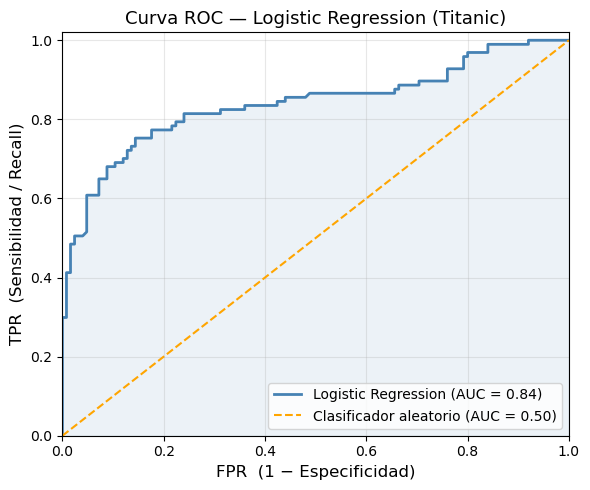


💡 AUC = 0.8397 → El modelo supera claramente al clasificador aleatorio.


In [22]:
fig, ax = plt.subplots(figsize=(6, 5))

# Curva ROC de Logistic Regression
ax.plot(fpr_lr, tpr_lr, color='steelblue', linewidth=2,
        label=f'Logistic Regression (AUC = {auc_lr:.2f})')

# Línea diagonal = clasificador aleatorio (AUC = 0.5)
ax.plot([0, 1], [0, 1], linestyle='--', color='orange', linewidth=1.5,
        label='Clasificador aleatorio (AUC = 0.50)')

# Sombrear el área bajo la curva
ax.fill_between(fpr_lr, tpr_lr, alpha=0.1, color='steelblue')

ax.set_xlabel('FPR  (1 − Especificidad)', fontsize=12)
ax.set_ylabel('TPR  (Sensibilidad / Recall)', fontsize=12)
ax.set_title('Curva ROC — Logistic Regression (Titanic)', fontsize=13)
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\n💡 AUC = {auc_lr:.4f} → El modelo supera claramente al clasificador aleatorio.')

## 🆚 Paso 5: Comparar Curvas ROC — LR vs DT

Sobreponemos las curvas de ambos modelos en el mismo gráfico para comparar visualmente su rendimiento.

Usando `RocCurveDisplay.from_estimator()` scikit-learn calcula las probabilidades, la curva ROC y el AUC internamente.

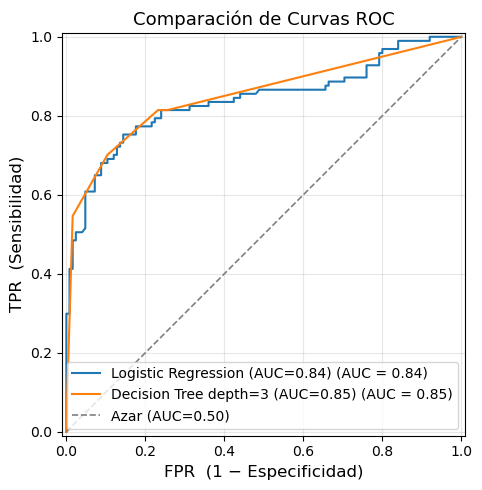


🏆 Mejor AUC: Decision Tree (AUC=0.8508)


In [23]:
fig, ax = plt.subplots(figsize=(7, 5))

# Con RocCurveDisplay de scikit-learn (forma compacta)
RocCurveDisplay.from_estimator(model_lr, X_test, y_test, ax=ax,
                                name=f'Logistic Regression (AUC={auc_lr:.2f})')
RocCurveDisplay.from_estimator(model_dt, X_test, y_test, ax=ax,
                                name=f'Decision Tree depth=3 (AUC={auc_dt:.2f})')

# Línea aleatoria
ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=1.2, label='Azar (AUC=0.50)')

ax.set_xlabel('FPR  (1 − Especificidad)', fontsize=12)
ax.set_ylabel('TPR  (Sensibilidad)', fontsize=12)
ax.set_title('Comparación de Curvas ROC', fontsize=13)
ax.legend(fontsize=10, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

ganador = 'Logistic Regression' if auc_lr > auc_dt else 'Decision Tree'
print(f'\n🏆 Mejor AUC: {ganador} (AUC={max(auc_lr, auc_dt):.4f})')

## 🔎 Paso 6: Entender los Puntos Clave de la Curva ROC

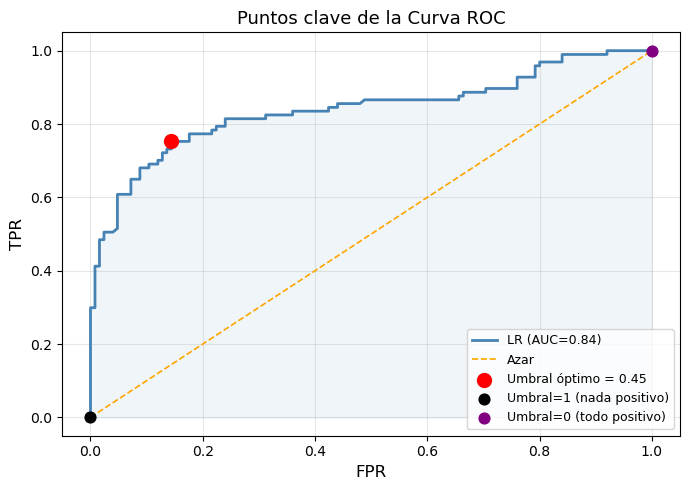


🎯 Umbral óptimo (min distancia a punto ideal (0,1)): 0.4473
   FPR en ese punto: 0.1440
   TPR en ese punto: 0.7526


In [18]:
# 🔎 Encontrar el umbral óptimo (distancia mínima al punto (0,1))
distancias = np.sqrt(fpr_lr**2 + (1 - tpr_lr)**2)
idx_optimo = np.argmin(distancias)
umbral_optimo = thresholds_lr[idx_optimo]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_lr, tpr_lr, color='steelblue', linewidth=2, label=f'LR (AUC={auc_lr:.2f})')
ax.plot([0, 1], [0, 1], '--', color='orange', linewidth=1.2, label='Azar')
ax.fill_between(fpr_lr, tpr_lr, alpha=0.08, color='steelblue')

# Punto óptimo
ax.scatter([fpr_lr[idx_optimo]], [tpr_lr[idx_optimo]],
           color='red', zorder=5, s=100, label=f'Umbral óptimo = {umbral_optimo:.2f}')

# Puntos extremos
ax.scatter([0], [0], color='black', zorder=5, s=60, label='Umbral=1 (nada positivo)')
ax.scatter([1], [1], color='purple', zorder=5, s=60, label='Umbral=0 (todo positivo)')

ax.set_xlabel('FPR', fontsize=12)
ax.set_ylabel('TPR', fontsize=12)
ax.set_title('Puntos clave de la Curva ROC', fontsize=13)
ax.legend(fontsize=9, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\n🎯 Umbral óptimo (min distancia a punto ideal (0,1)): {umbral_optimo:.4f}')
print(f'   FPR en ese punto: {fpr_lr[idx_optimo]:.4f}')
print(f'   TPR en ese punto: {tpr_lr[idx_optimo]:.4f}')

## 🏁 Conclusiones

En este notebook aprendimos:

1. 📉 La **Curva ROC** visualiza el trade-off entre Sensibilidad (TPR) y 1−Especificidad (FPR) para todos los umbrales posibles.
2. 📐 El **AUC** resume la curva en un número: 0.5 = azar, 1.0 = perfecto.
3. 🆚 Se pueden **comparar múltiples modelos** en el mismo gráfico ROC, eligiendo el que tenga mayor AUC.
4. 🎯 El **umbral óptimo** es el punto de la curva más cercano al vértice (0, 1): mínima distancia a la "perfección".
5. 📊 `RocCurveDisplay.from_estimator()` automatiza el proceso completo (probas → ROC → AUC → plot).

### ➡️ Próximo notebook: Validación Cruzada K-Fold

---

## 📚 Referencias

- Fawcett, T. (2006). [An introduction to ROC analysis](https://doi.org/10.1016/j.patrec.2005.10.010). *Pattern Recognition Letters*, 27(8), 861–874.
- Bradley, A. P. (1997). [The use of the area under the ROC curve in the evaluation of machine learning algorithms](https://doi.org/10.1016/S0031-3203(96)00142-2). *Pattern Recognition*, 30(7), 1145–1159.
- Scikit-learn: [roc_curve](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html)
- Scikit-learn: [RocCurveDisplay](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.RocCurveDisplay.html)